In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
import pingouin as pg

## Load Data Set

In [78]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "48-hour-exam/group_3_faa_data_subset/group_3_faa_data_subset/faa_data_subset.xlsx"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/master/{directory}"
df = pd.read_excel(github_url)


## Basic Data Inspection and Cleaning

In [79]:
# Display the shape of the dataframe
df.shape

(28298, 25)

In [80]:
# Display the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28298 entries, 0 to 28297
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Airport: Code                               28298 non-null  object        
 1   Airport: Name                               28298 non-null  object        
 2   Origin State                                28298 non-null  object        
 3   Origin State Code                           28298 non-null  object        
 4   Country                                     28298 non-null  object        
 5   Aircraft: Type                              27467 non-null  object        
 6   Aircraft: Number of engines                 25918 non-null  float64       
 7   Collision Date and Time                     28298 non-null  datetime64[ns]
 8   When: Time of day                           27655 non-null  object        
 9   When: 

In [81]:
# Display the first few rows of the dataframe
df.head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,...,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,...,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,...,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,...,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,...,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,...,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [82]:
# Display the summary statistics of the dataframe
df.describe().round(0)

,Aircraft: Number of engines,Collision Date and Time,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
count,25918.0,28298,2929.0,28298.0,2929.0,24872.0,19807.0,28298.0,28298.0
mean,2.0,2009-08-02 02:55:58.905929728,85.0,11385.0,4.0,339.0,0.0,1.0,271474.0
min,1.0,2000-01-02 10:27:00,0.0,0.0,0.0,0.0,0.0,1.0,1164.0
25%,2.0,2006-07-21 11:55:00,1.0,0.0,0.0,0.0,0.0,1.0,235364.0
50%,2.0,2010-07-17 07:42:00,2.0,0.0,0.0,0.0,0.0,1.0,301697.0
75%,2.0,2013-01-27 07:36:15,24.0,0.0,1.0,100.0,0.0,1.0,330425.0
max,4.0,2015-05-31 21:47:00,21000.0,41071585.0,875.0,20000.0,100.0,1.0,360842.0
std,0.0,NaN,509.0,312536.0,21.0,1065.0,3.0,0.0,81859.0


In [83]:
# display missing values

missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+--------------------------------------------+------------------+--------------+
|                                            |   Missing Values |   Percentage |
|--------------------------------------------+------------------+--------------|
| Cost: Aircraft time out of service (hours) |            25369 |     89.6494  |
| Days                                       |            25369 |     89.6494  |
| Effect: Impact to flight                   |            25265 |     89.2819  |
| Effect: Amount of damage (detailed)        |            25187 |     89.0063  |
| Miles from airport                         |             8491 |     30.0057  |
| Feet above ground                          |             3426 |     12.1069  |
| Aircraft: Number of engines                |             2380 |      8.41049 |
| Aircraft: Type                             |              831 |      2.9366  |
| When: Time of day                          |              643 |      2.27225 |
| When: Phase of flight     

In [ ]:
df.columns = (
    df.columns
      .str.replace('$', '', regex=False)
      .str.strip()
      .str.lower()
      .str.replace(':', '', regex=False)  
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

# Print the cleaned column names
print(df.columns)


Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')


In [85]:
#Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Basic Plots

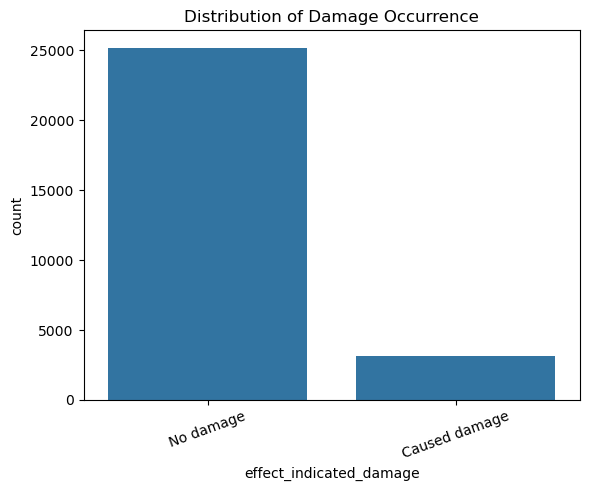

In [328]:
sns.countplot(data=df, x="effect_indicated_damage")
plt.title("Distribution of Damage Occurrence")
plt.xticks(rotation=20)
plt.show()

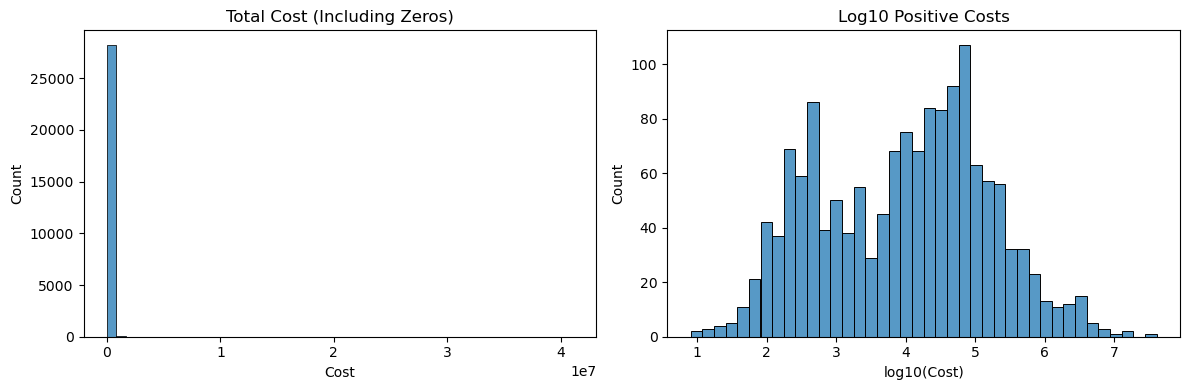

In [329]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: All costs (including zeros)
sns.histplot(df["cost_total"], bins=50, ax=axes[0])
axes[0].set_title("Total Cost (Including Zeros)")
axes[0].set_xlabel("Cost")

# Right: Log-transformed positive costs
log_positive_costs = np.log10(df.loc[df["cost_total"] > 0, "cost_total"])

sns.histplot(log_positive_costs, bins=40, ax=axes[1])
axes[1].set_title("Log10 Positive Costs")
axes[1].set_xlabel("log10(Cost)")

plt.tight_layout()
plt.show()

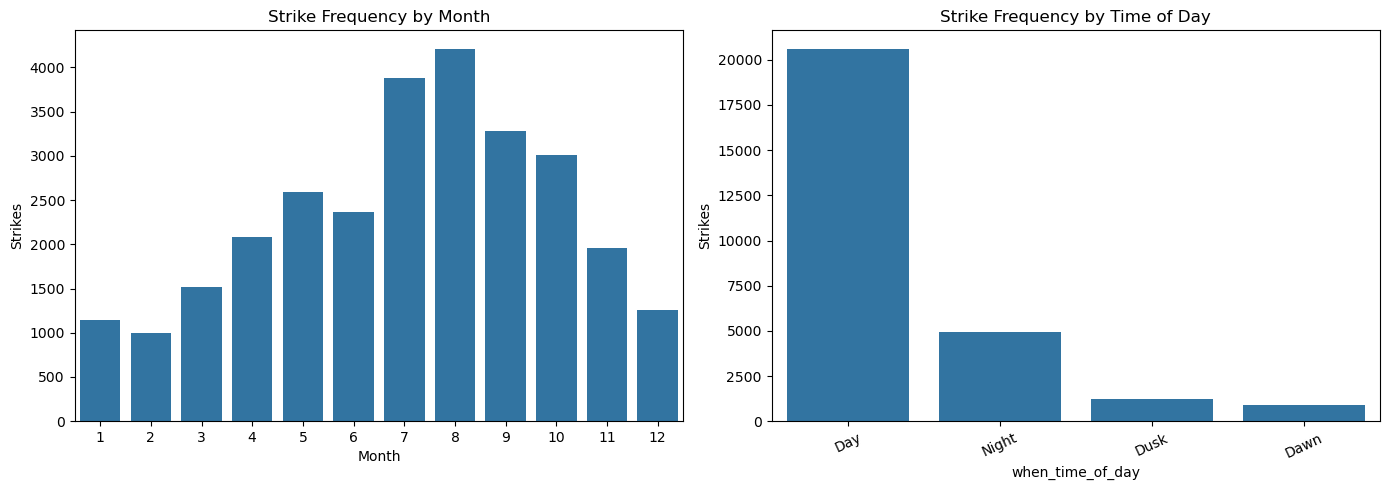

In [330]:
df["Month"] = df["collision_date_and_time"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, order, title in zip(
    axes,
    ["Month", "when_time_of_day"],
    [
        range(1, 13),
        df["when_time_of_day"].dropna().value_counts().index
    ],
    ["Strike Frequency by Month", "Strike Frequency by Time of Day"]
):
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_ylabel("Strikes")
    ax.tick_params(axis="x", rotation=25 if col == "when_time_of_day" else 0)

plt.tight_layout()
plt.show()

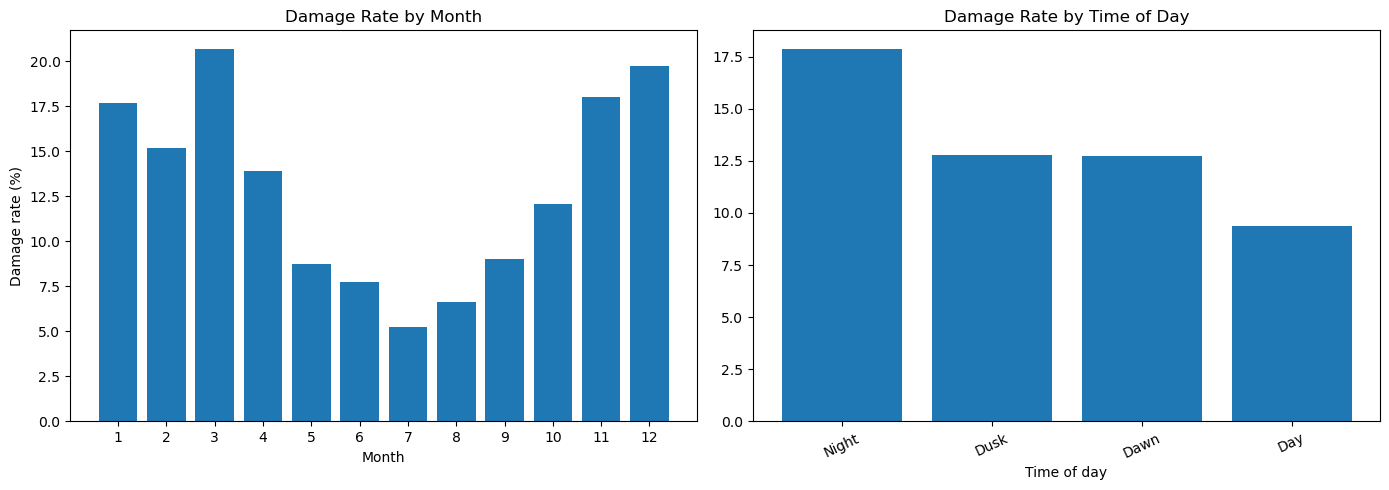

In [331]:

tmp = df.copy()
tmp["damage_flag"] = (tmp["effect_indicated_damage"] == "Caused damage").astype(int)
tmp["Month"] = tmp["collision_date_and_time"].dt.month

groups = {
    "Month": tmp.groupby("Month")["damage_flag"].mean().reindex(range(1, 13)) * 100,
    "when_time_of_day": tmp.groupby("when_time_of_day")["damage_flag"].mean().sort_values(ascending=False) * 100
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, rates) in zip(axes, groups.items()):
    ax.bar(rates.index.astype(str), rates.values)
    ax.set_title(f"Damage Rate by {'Month' if col=='Month' else 'Time of Day'}")
    ax.set_xlabel("Month" if col == "Month" else "Time of day")
    ax.set_ylabel("Damage rate (%)" if col == "Month" else "")
    ax.tick_params(axis="x", rotation=25 if col != "Month" else 0)

plt.tight_layout()
plt.show()

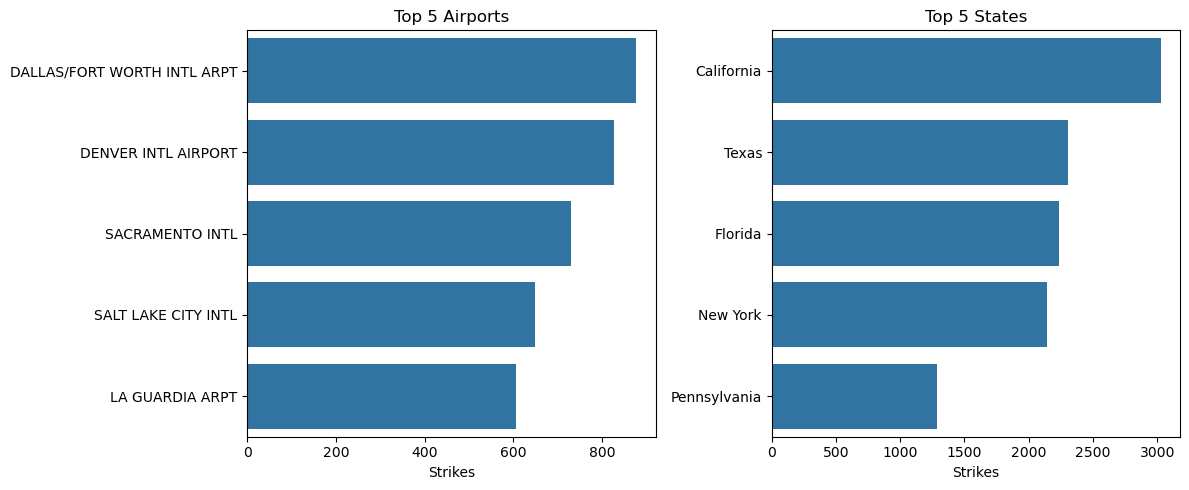

In [332]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ["airport_name", "origin_state"],
    ["Top 5 Airports", "Top 5 States"]
):
    top = df[col].fillna("Unknown").value_counts().head(5)
    sns.barplot(x=top.values, y=top.index, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Strikes")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

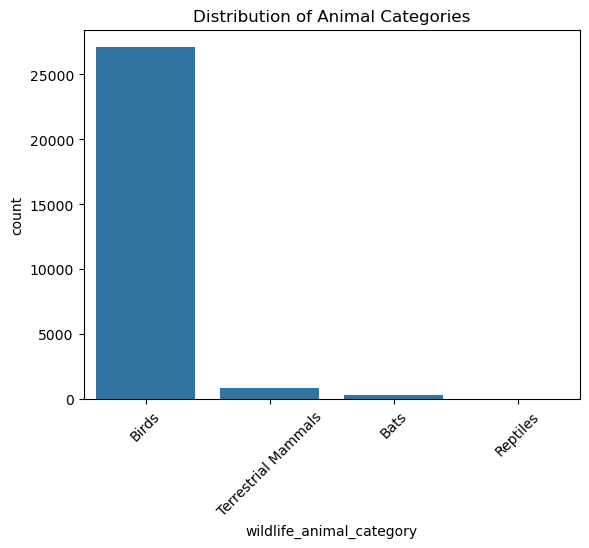

In [333]:
plt.figure()

sns.countplot(
    data=df,
    x="wildlife_animal_category",
    order=df["wildlife_animal_category"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribution of Animal Categories")
plt.show()

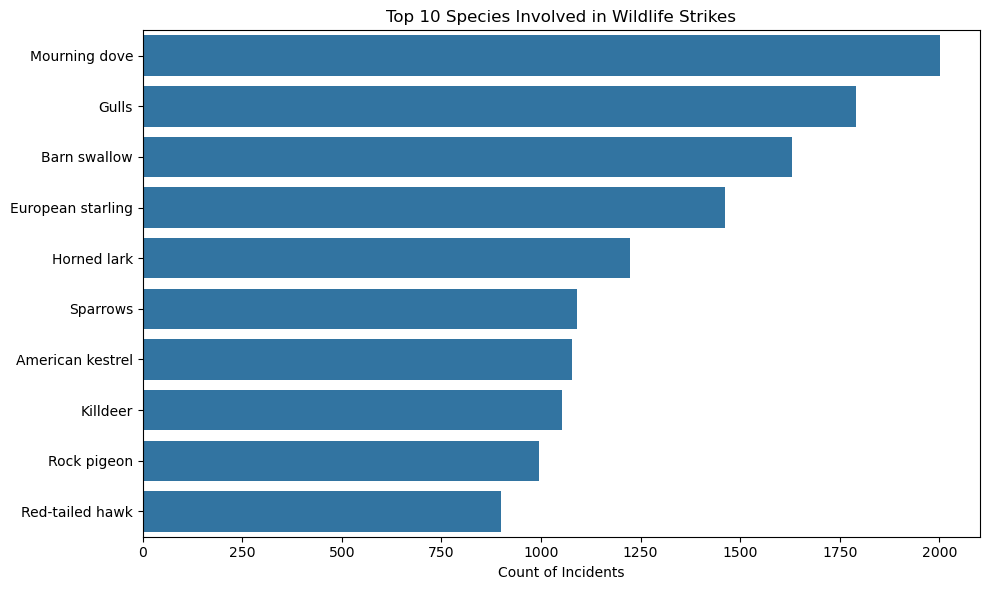

In [334]:
plt.figure(figsize=(10, 6))

top_species = (
    df["wildlife_species"]
      .fillna("Unknown")
      .value_counts()
      .head(10)
      .sort_values(ascending=False)  )

ax = sns.barplot(
    x=top_species.values,
    y=top_species.index
)

plt.title("Top 10 Species Involved in Wildlife Strikes")
plt.xlabel("Count of Incidents")
plt.ylabel("")  
plt.tight_layout()
plt.show()

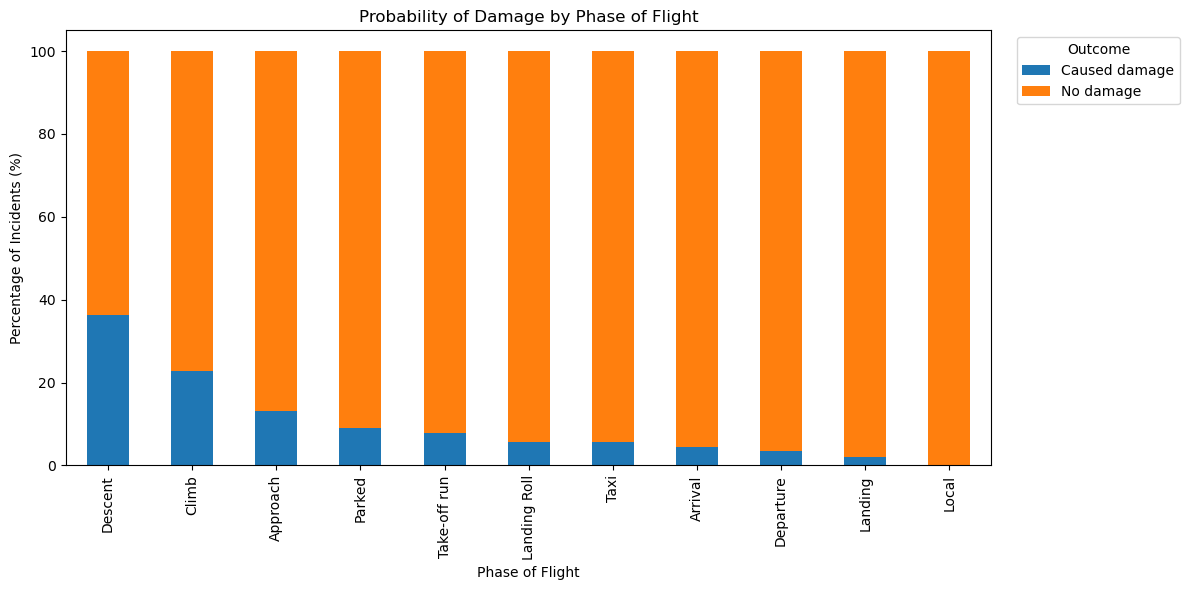

In [335]:
phase_damage = (
    pd.crosstab(
        df["when_phase_of_flight"],
        df["effect_indicated_damage"],
        normalize="index"
    ) * 100
)

# Sort by "Caused damage" if present; otherwise sort by first column
sort_col = "Caused damage" if "Caused damage" in phase_damage.columns else phase_damage.columns[0]
phase_damage = phase_damage.sort_values(by=sort_col, ascending=False)

ax = phase_damage.plot(kind="bar", stacked=True, figsize=(12, 6))
ax.set_title("Probability of Damage by Phase of Flight")
ax.set_ylabel("Percentage of Incidents (%)")
ax.set_xlabel("Phase of Flight")
ax.legend(title="Outcome", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

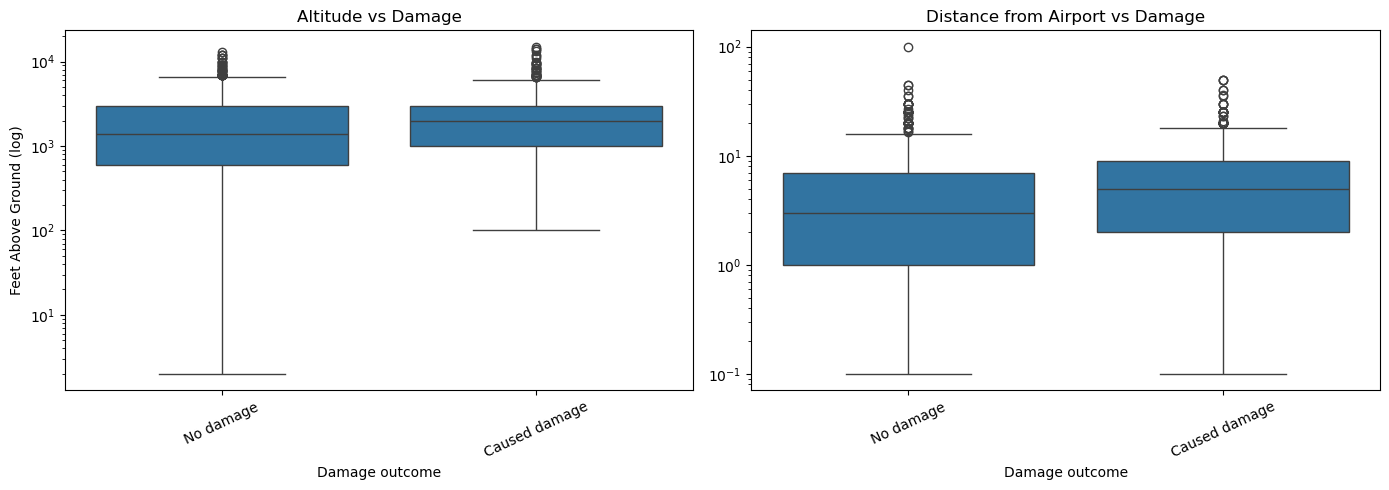

In [336]:
# Keep positive values
plot_df = df.dropna(subset=["feet_above_ground", "miles_from_airport"])
plot_df = plot_df[(plot_df["feet_above_ground"] > 0) & (plot_df["miles_from_airport"] > 0)]

# Order categories once
order = (
    plot_df.groupby("effect_indicated_damage")["feet_above_ground"]
           .median()
           .sort_values()
           .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel in zip(
    axes,
    ["feet_above_ground", "miles_from_airport"],
    ["Altitude vs Damage", "Distance from Airport vs Damage"],
    ["Feet Above Ground (log)", ""]
):
    sns.boxplot(data=plot_df, x="effect_indicated_damage", y=col, order=order, ax=ax)
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_xlabel("Damage outcome")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()